In [1]:
import h5py
import scipy.io as io
from PIL import Image
import numpy as np
import os
import glob
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter
import scipy
import json
from tqdm import tqdm

from matplotlib import cm as CM
%matplotlib inline

In [2]:
def gaussian_filter_density(gt):
    #Genreate density map using Gaussian filter

    density = np.zeros(gt.shape, dtype=np.float32)

    gt_count = np.count_nonzero(gt)

    if gt_count == 0:
        return density
    
    pts = np.array(list(zip(np.nonzero(gt)[1].ravel(), np.nonzero(gt)[0].ravel())))
    leafsize = 2048

    # build kdtree
    tree = scipy.spatial.KDTree(pts.copy(), leafsize=leafsize)

    # query kdtree
    distances, locations = tree.query(pts, k=4)

    for i, pt in enumerate(pts):
        pt2d = np.zeros(gt.shape, dtype=np.float32)
        pt2d[pt[1],pt[0]] = 1.
        if gt_count > 1:
            sigma = (distances[i][1]+distances[i][2]+distances[i][3])*0.1
        else:
            sigma = np.average(np.array(gt.shape))/2./2. #case: 1 point
        
        #Convolve with the gaussian filter
        
        density += gaussian_filter(pt2d, sigma, mode='constant')
    
    return density

In [3]:
root = os.path.join(os.getcwd(), 'data')
print(root)

c:\Users\User\OneDrive\Desktop\crowd_counting_project\data


In [5]:
part_A_train = os.path.join(root,'part_A_final/train_data','images')
part_A_test = os.path.join(root,'part_A_final/test_data','images')
part_B_train = os.path.join(root,'part_B_final/train_data','images')
part_B_test = os.path.join(root,'part_B_final/test_data','images')
path_sets = [part_B_train,part_B_test]

In [6]:
# List of all image paths

img_paths = []
for path in tqdm(path_sets):
    for img_path in glob.glob(os.path.join(path, '*.jpg')):
        img_paths.append(img_path)
print(len(img_paths))

100%|██████████| 2/2 [00:00<00:00, 485.48it/s]

716


In [9]:
i = 0
for img_path in tqdm(img_paths):
        
    
    # Load sparse matrix
    mat = io.loadmat(img_path.replace('.jpg','.mat').replace('images','ground_truth').replace('IMG_','GT_IMG_'))
    
    #Read image
    img= plt.imread(img_path)
    
    # Create a zero matrix of image size
    k = np.zeros((img.shape[0],img.shape[1]))
    
    gt = mat["image_info"][0,0][0,0][0]
    
    # Generate hot encoded matrix of sparse matrix
    for i in range(0,len(gt)):
       if int(gt[i][1])<img.shape[0] and int(gt[i][0])<img.shape[1]:
           k[int(gt[i][1]),int(gt[i][0])]=1
    
    # generate density map
    k = gaussian_filter_density(k)
    
    # File path to save density map
    file_path = img_path.replace('.jpg','.h5').replace('images','ground_truth')
    
    with h5py.File(file_path, 'w') as hf:
           hf['density'] = k

  1%|▏         | 10/716 [01:25<1:40:11,  8.52s/it]


KeyboardInterrupt: 

In [ ]:
file_path = os.path.join(os.getcwd(),img_paths[22].replace('.jpg','.h5').replace('images','ground_truth') )
print(file_path)

c:\Users\User\Desktop\crowd_counting_project\data\part_B_final/train_data\ground_truth\IMG_119.h5


Sum =  300.65756
c:\Users\User\Desktop\crowd_counting_project\data\part_B_final/train_data\ground_truth\IMG_119.h5


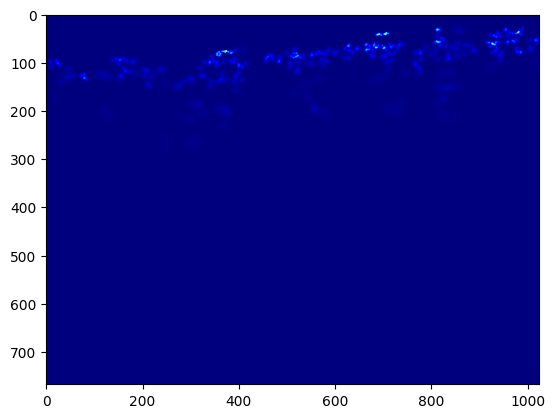

In [ ]:
#Sample Ground Truth
gt_file = h5py.File(file_path,'r')
groundtruth = np.asarray(gt_file['density'])
plt.imshow(groundtruth,cmap=CM.jet)
print("Sum = " ,np.sum(groundtruth))
print(file_path)

c:\Users\User\OneDrive\Desktop\crowd_counting_project\data\part_B_final/train_data\ground_truth\IMG_113.h5


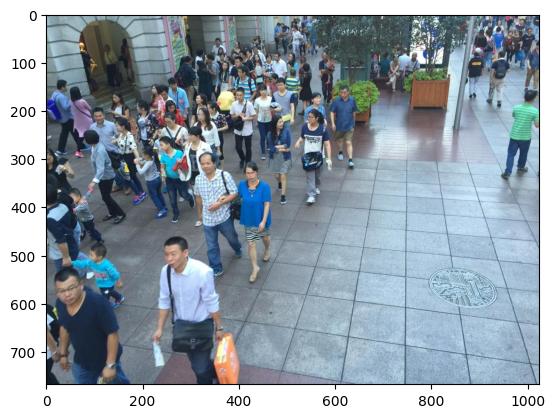

In [8]:
# Image corresponding to the ground truth
img = Image.open(file_path.replace('.h5','.jpg').replace('ground_truth','images'))
plt.imshow(img)
print(file_path)

In [11]:
import os
import h5py
import numpy as np

# Random array to save
arr = np.random.randn(1000)

# ✅ Your desired file path
file_path = r"c:\Users\User\OneDrive\Desktop\crowd_counting_project\data\part_B_final\train_data\ground_truth\IMG_113.h5"

# ✅ Ensure the directory exists
os.makedirs(os.path.dirname(file_path), exist_ok=True)

# ✅ Create and save .h5 file
with h5py.File(file_path, 'w') as f:
    f.create_dataset("default", data=arr)

print("✅ File saved successfully at:", file_path)


✅ File saved successfully at: c:\Users\User\OneDrive\Desktop\crowd_counting_project\data\part_B_final\train_data\ground_truth\IMG_113.h5


In [12]:
os.getcwd()

'c:\\Users\\User\\OneDrive\\Desktop\\crowd_counting_project'

In [13]:
len(gt)

209

In [14]:
print(k)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [15]:
pts = np.array(list(zip(np.nonzero(k)[1].ravel(), np.nonzero(k)[0].ravel())))

In [16]:
pts.shape

(209, 2)

In [17]:
i=int(0)
for pt in pts:
    print(pt)
    i+=1
    if i==50:
        break

[900 148]
[738 149]
[752 149]
[773 150]
[911 150]
[719 151]
[886 154]
[187 156]
[756 156]
[203 157]
[195 158]
[736 158]
[747 159]
[762 159]
[779 159]
[562 160]
[567 160]
[811 160]
[927 160]
[564 161]
[805 161]
[685 163]
[736 164]
[776 164]
[582 165]
[727 165]
[530 168]
[714 169]
[271 171]
[738 171]
[534 172]
[930 172]
[264 173]
[792 173]
[718 174]
[169 175]
[693 175]
[723 175]
[183 176]
[667 176]
[799 176]
[713 177]
[  5 178]
[508 178]
[515 178]
[749 178]
[659 179]
[303 180]
[823 180]
[660 181]
